# 02 — Pré-processamento

**Dimensão 4 da rúbrica — 15 pontos.**

Cada decisão precisa de justificativa escrita. Decidir *não* criar features é
aceitável, desde que o motivo esteja explícito.

In [64]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np

# Semente fixa: use em TODO ponto com aleatoriedade (split, modelos, CV).
RANDOM_STATE = 42

RAW = Path("..") / "data" / "raw" / "dataset.csv"          # PREENCHER: nome do arquivo
PROCESSED = Path("..") / "data" / "processed"
TARGET = Path("..") / "data" / "processed" / "target.csv"    # PREENCHER: variável alvo

APPLICATION = Path("..") / "data" / "raw" / "application_record.csv"          # PREENCHER: nome do arquivo
CREDIT = Path("..") / "data" / "raw" / "credit_record.csv" 

pd.set_option("display.max_columns", None)

In [65]:
credit = pd.read_csv(CREDIT)

In [66]:
application_raw = pd.read_csv(APPLICATION)

## 1. Dados faltantes

In [24]:
#nulos = df.isna().sum()
#pd.DataFrame({"nulos": nulos, "pct": (nulos / len(df) * 100).round(2)}).query("nulos > 0")

In [67]:
nulos = application_raw.isna().sum()
pd.DataFrame({"nulos": nulos, "%": (nulos / len(application_raw) * 100).round(2)}).query("nulos > 0")

,nulos,%
OCCUPATION_TYPE,134203,30.6


In [68]:
application_raw['NAME_INCOME_TYPE'].value_counts().sort_index()

NAME_INCOME_TYPE
Commercial associate    100757
Pensioner                75493
State servant            36186
Student                     17
Working                 226104
Name: count, dtype: int64

Olhando a categoria "NAME_INCOME_TYPE", observa-se que traz 5 grandes grupos, que podem ser utilizados como substitutos para os dados nulos da categoria "OCCUPATION_TYPE", trazendo uma melhor caracterização do que a simples substituição para "Desconhecido" ("Unknown") ou mesmo a exclusão do cliente do dataset. Nesse sentido, será criada uma nova coluna no dataset "application_raw", substituindo os valores nulos pelo dado em "NAME_INCOME_TYPE"

In [69]:
#Ajustando a variável OCCUPATION_TYPE, que possui valores nulos, para o valor da variável NAME_INCOME_TYPE, quando OCCUPATION_TYPE for nulo. Caso contrário, mantém o valor original de OCCUPATION_TYPE. Criando uma nova variável chamada OCCUPATION_TYPE_ADJUSTED.
application_raw['OCCUPATION_TYPE_ADJUSTED'] = np.where(application_raw['OCCUPATION_TYPE'].isnull(),application_raw['NAME_INCOME_TYPE'], application_raw['OCCUPATION_TYPE'])
application_raw.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,OCCUPATION_TYPE_ADJUSTED
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,Working
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,Working
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0,Security staff
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,Sales staff
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,Sales staff


**Decisão:** _preencher._

## 2. Definição da variável alvo

_Se houve binarização, qual limiar e por quê? Justifique com base na distribuição, não por convenção._

In [6]:
# ex.: df['alvo'] = (df[TARGET] >= LIMIAR).astype(int)

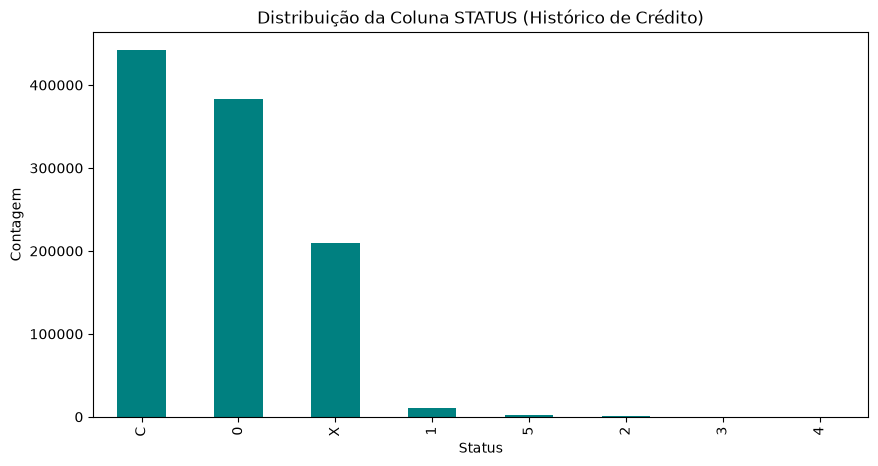


* Distribuição dos Status de Crédito (%):
 STATUS
C    42.16
0    36.54
X    19.95
1     1.06
5     0.16
2     0.08
3     0.03
4     0.02
Name: proportion, dtype: float64


In [71]:
plt.figure(figsize=(10, 5))
credit['STATUS'].value_counts().plot(kind='bar', color='teal')
plt.title('Distribuição da Coluna STATUS (Histórico de Crédito)')
plt.xlabel('Status')
plt.ylabel('Contagem')
plt.show()

# Proporção
print("\n* Distribuição dos Status de Crédito (%):\n",credit['STATUS'].value_counts(normalize=True).round(4)* 100)

Observando a distribuição da categoria 'STATUS', verifica-se uma concentração dos dados no grupo de bons pagadores (C: quitado no mês em análise | X: sem empréstimo no mês em análise). Vale lembrar que essa primeira visualização pode conter dados repetidos para clientes, visto que se trata de histórico de crédito.

In [76]:
#Criação da variável TARGET no dataset de crédito
credit['TARGET0'] = credit['STATUS'].apply(lambda x: 1 if x in ['0','1', '2', '3', '4', '5'] else 0)
credit['TARGET1'] = credit['STATUS'].apply(lambda x: 1 if x in ['1', '2', '3', '4', '5'] else 0)
credit['TARGET2'] = credit['STATUS'].apply(lambda x: 1 if x in ['2', '3', '4', '5'] else 0)
credit['TARGET3'] = credit['STATUS'].apply(lambda x: 1 if x in ['3', '4', '5'] else 0)
credit['TARGET4'] = credit['STATUS'].apply(lambda x: 1 if x in ['4', '5'] else 0)
credit['TARGET5'] = credit['STATUS'].apply(lambda x: 1 if x in ['5'] else 0)

target0 = credit.groupby('ID')['TARGET0'].max().reset_index()
target1 = credit.groupby('ID')['TARGET1'].max().reset_index()
target2 = credit.groupby('ID')['TARGET2'].max().reset_index()
target3 = credit.groupby('ID')['TARGET3'].max().reset_index()
target4 = credit.groupby('ID')['TARGET4'].max().reset_index()
target5 = credit.groupby('ID')['TARGET5'].max().reset_index()

pct_targets = pd.DataFrame({
    "Atraso >= 1 dia": target0['TARGET0'].value_counts(normalize=True).round(4) * 100,
    "Atraso >= 30 dias": target1['TARGET1'].value_counts(normalize=True).round(4) * 100,
    "Atraso >= 60 dias": target2['TARGET2'].value_counts(normalize=True).round(4) * 100,
    "Atraso >= 90 dias": target3['TARGET3'].value_counts(normalize=True).round(4) * 100,
    "Atraso >= 120 dias": target4['TARGET4'].value_counts(normalize=True).round(4) * 100,  
     "Atraso >= 150 dias": target5['TARGET5'].value_counts(normalize=True).round(4) * 100  
}).rename(index={0: "bom pagador (0)", 1: "mau pagador (1)"})

print("\n* Quantidade de IDs (clientes) únicos:\n", credit['ID'].nunique())
display(pct_targets)



* Quantidade de IDs (clientes) únicos:
 45985


,Atraso >= 1 dia,Atraso >= 30 dias,Atraso >= 60 dias,Atraso >= 90 dias,Atraso >= 120 dias,Atraso >= 150 dias
bom pagador (0),12.95,88.37,98.55,99.28,99.47,99.58
mau pagador (1),87.05,11.63,1.45,0.72,0.53,0.42


Aqui, é trazida a análise diversos níveis para a classificação entre bons e maus pagadores, desde o mais rígido (atraso a partir de 1 dia) até o mais flexível (atraso maior ou igual a 150 dias), considerando o pior status de um cliente ao longo de seus registros de crédito. 

Nesse contexto, é possível observar que para atrasos maiores ou iguais a 30 dias, eleva-se a proporção de clientes indicados como bons pagadores. Nesse sentido, quanto mais flexível o nível de atraso, maior a chance de o modelo de aprendizado de máquina indicar como bom pagador um cliente alta chance de inadimplência. 

Por outro lado, atrasos entre 1 e 29 dias não necessariamente representam um risco iminente de inadimplência e quando adotado um critério mais rígido, o modelo de aprendizado de máquina indicar como mau pagador um cliente com baixas chances de inadimplência. 

Dessa forma, para o trabalho de aprendizado de máquina a ser desenvolvido neste projeto, será considerado como risco de aumento de inadimplência clientes com atrasos a partir de 30 dias (categoria 'TARGET1' no dataset 'credit'):
- Mau pagador (TARGET1 = 1): Clientes com algum registro de atraso de 30 dias ou mais (STATUS = 1, 2, 3, 4, 5) em algum mês do histórico de crédito
- Bom pagador (TARGET1 = 0): Clientes sem registro de atraso de 30 dias ou mais (STATUS = 0, C, X) em todos os meses do histórico de crédito



In [73]:
credit.head()

,ID,MONTHS_BALANCE,STATUS,TARGET0,TARGET1,TARGET2,TARGET3,TARGET4,TARGET5
0,5001711,0,X,0,0,0,0,0,0
1,5001711,-1,0,1,0,0,0,0,0
2,5001711,-2,0,1,0,0,0,0,0
3,5001711,-3,0,1,0,0,0,0,0
4,5001712,0,C,0,0,0,0,0,0


In [91]:
application_record = application_raw.drop_duplicates(subset="ID", keep="first")

application_merge = application_record.merge(target0, on="ID", how="inner")

application_merge = application_merge.merge(target1, on="ID", how="inner")
application_merge = application_merge.merge(target2, on="ID", how="inner")
application_merge = application_merge.merge(target3, on="ID", how="inner")
application_merge = application_merge.merge(target4, on="ID", how="inner")
application_merge = application_merge.merge(target5, on="ID", how="inner")

application_merge.head()



,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,OCCUPATION_TYPE_ADJUSTED,TARGET0,TARGET1,TARGET2,TARGET3,TARGET4,TARGET5
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,Working,1,1,0,0,0,0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,Working,1,1,0,0,0,0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0,Security staff,1,0,0,0,0,0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,Sales staff,1,0,0,0,0,0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,Sales staff,0,0,0,0,0,0


In [93]:

pct_targets_merge = pd.DataFrame({
    "Atraso >= 1 dia": application_merge['TARGET0'].value_counts(normalize=True).round(4) * 100,
    "Atraso >= 30 dias": application_merge['TARGET1'].value_counts(normalize=True).round(4) * 100,
    "Atraso >= 60 dias": application_merge['TARGET2'].value_counts(normalize=True).round(4) * 100,
    "Atraso >= 90 dias": application_merge['TARGET3'].value_counts(normalize=True).round(4) * 100,
    "Atraso >= 120 dias": application_merge['TARGET4'].value_counts(normalize=True).round(4) * 100,  
    "Atraso >= 150 dias": application_merge['TARGET5'].value_counts(normalize=True).round(4) * 100  
}).rename(index={0: "bom pagador (0)", 1: "mau pagador (1)"})

display(pct_targets_merge)

print("\n* Quantidade de clientes únicos com cadastro ANTES do cruzamento:\n", application_raw['ID'].nunique())

print("\n* Quantidade clientes únicos com histórico de crédito:\n", credit['ID'].nunique())

print("\n* Quantidade de clientes únicos com cadastro APÓS o cruzamento:\n", application_merge['ID'].nunique())

print("\n* Clientes descartados da análise, com registro de crédito e sem cadastro:\n", credit['ID'].nunique() - application_merge['ID'].nunique())

print("\n* Clientes descartados da análise, sem registro de crédito e com cadastro:\n", application_raw['ID'].nunique() - application_merge['ID'].nunique())

,Atraso >= 1 dia,Atraso >= 30 dias,Atraso >= 60 dias,Atraso >= 90 dias,Atraso >= 120 dias,Atraso >= 150 dias
bom pagador (0),12.22,88.23,98.31,99.17,99.38,99.51
mau pagador (1),87.78,11.77,1.69,0.83,0.62,0.49



* Quantidade de clientes únicos com cadastro ANTES do cruzamento:
 438510

* Quantidade clientes únicos com histórico de crédito:
 45985

* Quantidade de clientes únicos com cadastro APÓS o cruzamento:
 36457

* Clientes descartados da análise, com registro de crédito e sem cadastro:
 9528

* Clientes descartados da análise, sem registro de crédito e com cadastro:
 402053


Foi realizado o cruzamento da base de cadastro (application) com os targets no registro de crédito (credit). Seguem os pontos de destaque:

- Do universo de 438510 clientes, apenas 36457 têm cadastro e histórico de crédito, ou seja, são ~8% de dados completos para modelagem.
- na análise de target por período de atraso, o padrão observado no dataset credit se mantém - para atrasos maiores ou iguais a 30 dias, eleva-se a proporção de clientes indicados como bons pagadores. 

## 3. Normalização / padronização

**Escolha e justificativa:** _StandardScaler, MinMaxScaler ou nenhum?_

Aplique preferencialmente dentro de um `Pipeline` no notebook 03 — ajustar o scaler antes do split vaza informação do teste para o treino.

In [ ]:
# escala

## 4. Feature engineering

**Justificativa:** _preencher._

In [ ]:
# novas variáveis derivadas

Na EDA, verificou-se que as variáveis 'DAYS_BIRTH' e 'DAYS_EMPLOYED' estavam em dias. Para facilitar a análise, vale convertê-las para escala de anos

In [96]:
#Ajustando as variáveis DAYS_BIRTH e DAYS_EMPLOYED para anos, criando novas variáveis YEARS_BIRTH e YEARS_EMPLOYED
application_merge['YEARS_BIRTH'] = abs(application_merge['DAYS_BIRTH']) / 365

application_merge['YEARS_EMPLOYED'] = np.where(application_merge['DAYS_EMPLOYED'] < 0,abs(application_merge['DAYS_EMPLOYED']) / 365, 0)

application_merge.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,OCCUPATION_TYPE_ADJUSTED,TARGET0,TARGET1,TARGET2,TARGET3,TARGET4,TARGET5,YEARS_BIRTH,YEARS_EMPLOYED
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,Working,1,1,0,0,0,0,32.890411,12.443836
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,Working,1,1,0,0,0,0,32.890411,12.443836
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0,Security staff,1,0,0,0,0,0,58.832877,3.106849
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,Sales staff,1,0,0,0,0,0,52.356164,8.358904
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,Sales staff,0,0,0,0,0,0,52.356164,8.358904


In [99]:
application_final = application_merge.drop(columns=['DAYS_BIRTH', 'DAYS_EMPLOYED', 'OCCUPATION_TYPE','TARGET1', 'TARGET2', 'TARGET3', 'TARGET4', 'TARGET5'])
application_final = application_final.rename(columns={"TARGET0": "TARGET"})
application_final.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,OCCUPATION_TYPE_ADJUSTED,TARGET,YEARS_BIRTH,YEARS_EMPLOYED
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,1,1,0,0,2.0,Working,1,32.890411,12.443836
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,1,1,0,0,2.0,Working,1,32.890411,12.443836
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,1,0,0,0,2.0,Security staff,1,58.832877,3.106849
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,1,0,1,1,1.0,Sales staff,1,52.356164,8.358904
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,1,0,1,1,1.0,Sales staff,0,52.356164,8.358904


## 5. Salvar dataset tratado

In [101]:
PROCESSED.mkdir(parents=True, exist_ok=True)
application_final.to_csv(PROCESSED / "dataset_tratado.csv", index=False)